In [27]:
## Import Packages

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [28]:
# Load data
data = pd.read_csv("bitcoin_data/raw/btc_1h.csv")

In [29]:
data.head()

,datetime,open,high,low,close,volume
0,2020-01-01 00:00:00,7195.24,7196.25,7175.46,7177.02,511.814901
1,2020-01-01 01:00:00,7176.47,7230.00,7175.71,7216.27,883.052603
2,2020-01-01 02:00:00,7215.52,7244.87,7211.41,7242.85,655.156809
3,2020-01-01 03:00:00,7242.66,7245.00,7220.00,7225.01,783.724867
4,2020-01-01 04:00:00,7225.00,7230.00,7215.03,7217.27,467.812578


In [30]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 55958 entries, 0 to 55957
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  55958 non-null  str    
 1   open      55958 non-null  float64
 2   high      55958 non-null  float64
 3   low       55958 non-null  float64
 4   close     55958 non-null  float64
 5   volume    55958 non-null  float64
dtypes: float64(5), str(1)
memory usage: 2.6 MB


In [31]:
df = data.copy()

In [32]:
df.isnull().sum()

datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

In [33]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")
df = df.set_index("datetime")

In [35]:
series = df["volume"].pct_change()

series = series.replace([np.inf, -np.inf], np.nan).dropna()

quick_stationarity(series, "volume_pct_change")

volume_pct_change               p=0.0000  ✓ Stationary


### Stationarity

In [37]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

def quick_stationarity(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    status = "✓ Stationary" if result[1] < 0.05 else "✗ Non-stationary"
    print(f"{name:30s}  p={result[1]:.4f}  {status}")

# Test raw columns
quick_stationarity(df['close'],                        'close (raw)')
quick_stationarity(np.log(df['close']),                'log(close)')
quick_stationarity(np.log(df['close']).diff().dropna(),'log_return (1st diff)')
quick_stationarity(df['volume'],                       'volume (raw)')
quick_stationarity(np.log1p(df['volume']),             'log_volume')
#quick_stationarity(df['volume'].pct_change().dropna(), 'volume_pct_change')

close (raw)                     p=0.6231  ✗ Non-stationary
log(close)                      p=0.2985  ✗ Non-stationary
log_return (1st diff)           p=0.0000  ✓ Stationary
volume (raw)                    p=0.0000  ✓ Stationary
log_volume                      p=0.0000  ✓ Stationary


In [39]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF: H0 = non-stationary. Reject (p<0.05) means stationary
# KPSS: H0 = stationary. Reject (p<0.05) means non-stationary
# You want: ADF p<0.05  AND  KPSS p>0.05

log_return = np.log(df['close'] / df['close'].shift(1)).dropna()

adf_stat, adf_p, _, _, _, _ = adfuller(log_return, autolag='AIC')
kpss_stat, kpss_p, _, _     = kpss(log_return, regression='c', nlags='auto')

print(f"ADF  p = {adf_p:.4f}  → {'Stationary ✓' if adf_p < 0.05 else 'Non-stationary ✗'}")
print(f"KPSS p = {kpss_p:.4f} → {'Stationary ✓' if kpss_p > 0.05 else 'Non-stationary ✗'}")
# Both should confirm stationary now
# This gives you d=1 for ARIMA(p,1,q) — or d=0 if you feed log_return directly

ADF  p = 0.0000  → Stationary ✓
KPSS p = 0.1000 → Stationary ✓


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_2874/1049639733.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _     = kpss(log_return, regression='c', nlags='auto')


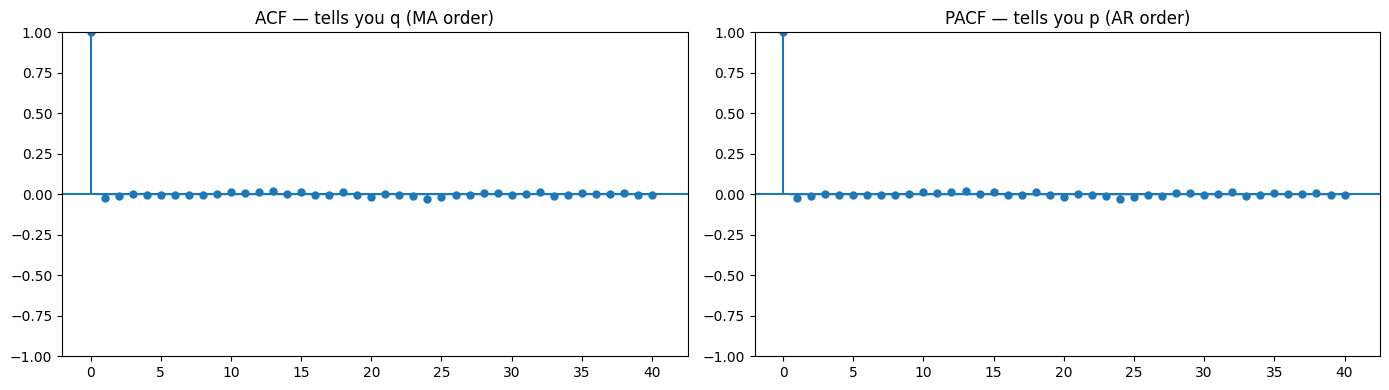

In [40]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(log_return, lags=40, ax=axes[0],
         title='ACF — tells you q (MA order)')
plot_pacf(log_return, lags=40, ax=axes[1],
          title='PACF — tells you p (AR order)', method='ywm')

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

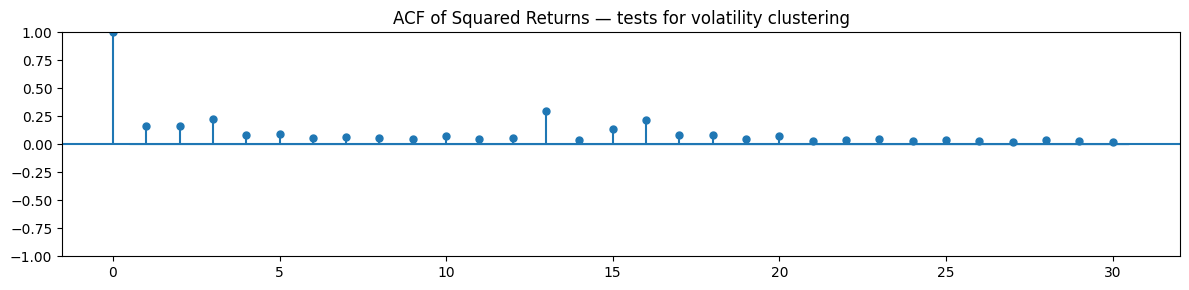

ARCH test p = 0.0000
Volatility clustering present ✓


In [41]:
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf

# Test for ARCH effects on squared returns
squared_returns = log_return ** 2

fig, ax = plt.subplots(figsize=(12, 3))
plot_acf(squared_returns, lags=30, ax=ax,
         title='ACF of Squared Returns — tests for volatility clustering')
plt.tight_layout()
plt.show()

# Engle's ARCH test (H0: no ARCH effects)
arch_stat, arch_p, _, _ = het_arch(log_return, nlags=10)
print(f"ARCH test p = {arch_p:.4f}")
print("Volatility clustering present ✓" if arch_p < 0.05
      else "No ARCH effects detected")

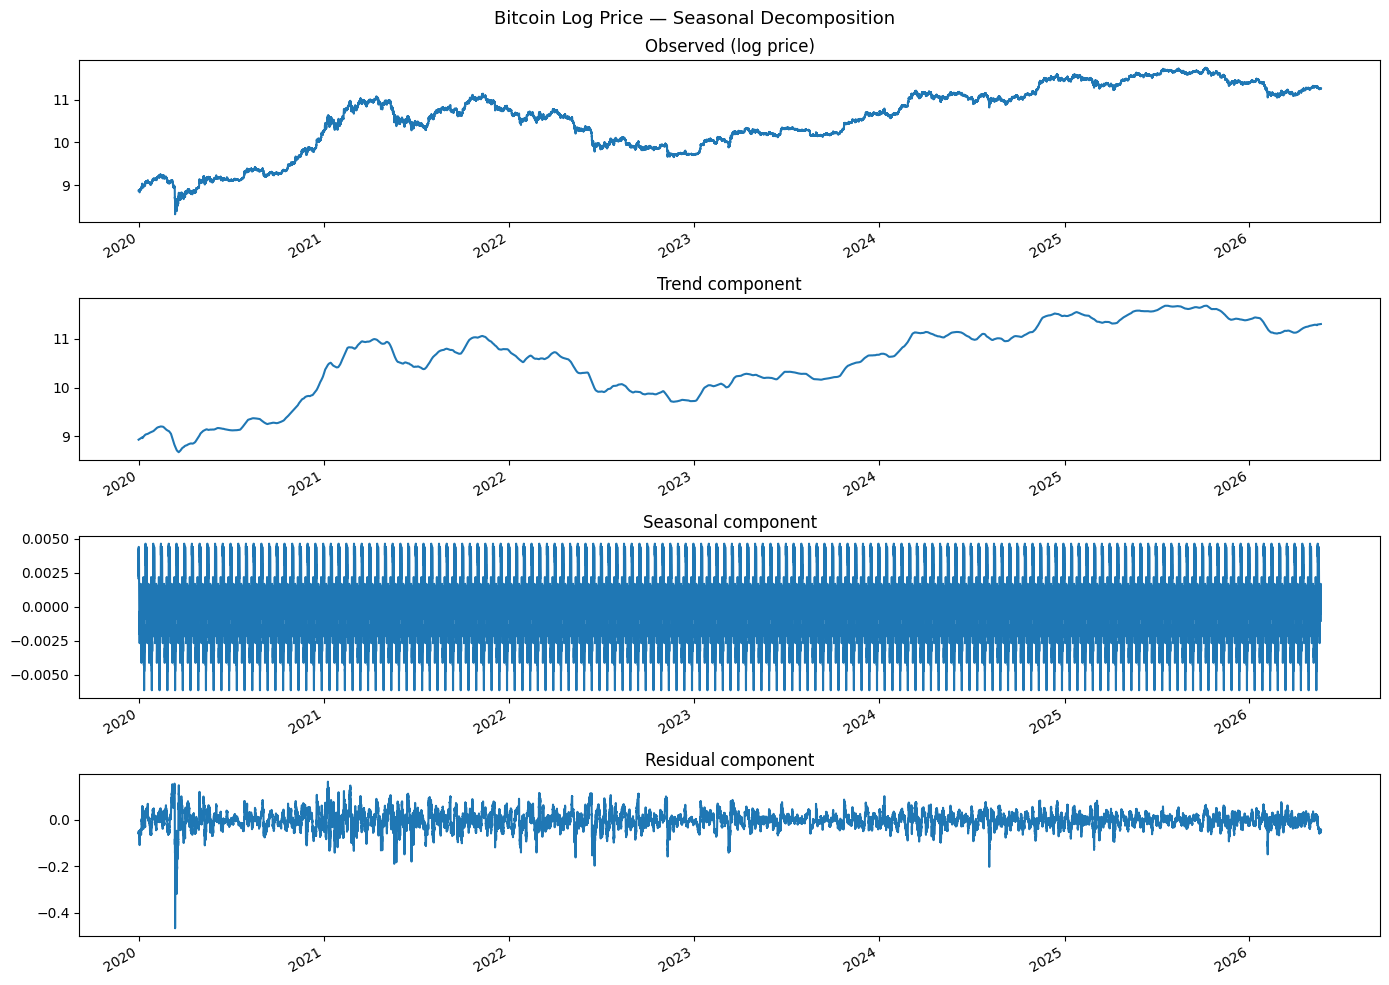

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use log(close) for decomposition — easier to interpret than returns
log_close = np.log(df['close']).dropna()

# Use daily data, period=365 for annual seasonality
# or period=7 for weekly cycle
decomp = seasonal_decompose(log_close, model='additive',
                            period=365, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0],  title='Observed (log price)')
decomp.trend.plot(ax=axes[1],     title='Trend component')
decomp.seasonal.plot(ax=axes[2],  title='Seasonal component')
decomp.resid.plot(ax=axes[3],     title='Residual component')

for ax in axes:
    ax.set_xlabel('')
plt.suptitle('Bitcoin Log Price — Seasonal Decomposition', fontsize=13)
plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=150)
plt.show()

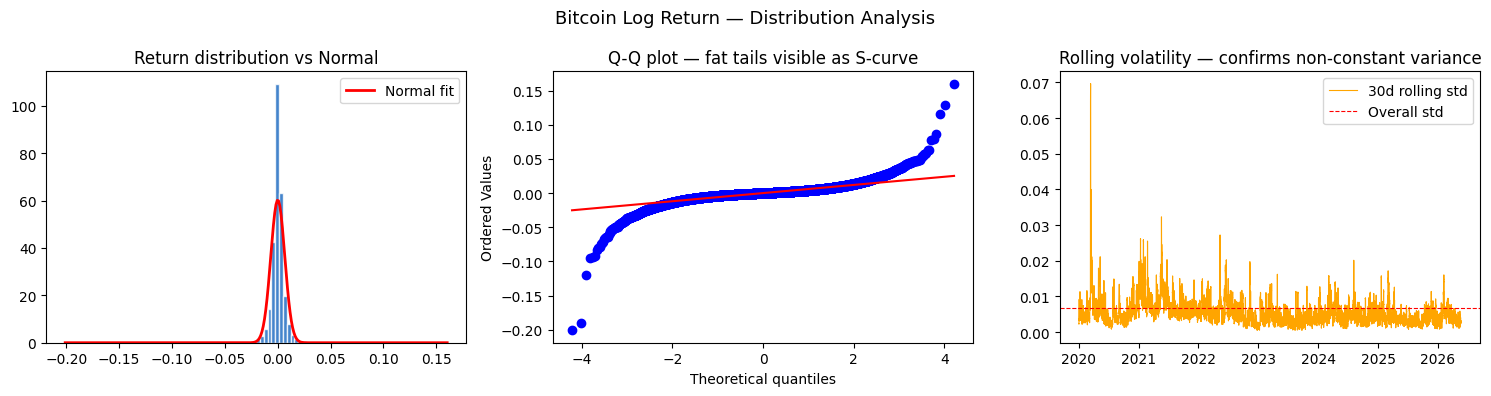

Mean return   : 0.0043%
Std  return   : 0.6620%
Skewness      : -0.9398  (negative = more big crashes than rallies)
Kurtosis      : 53.8483  (>3 = fat tails, extreme moves more common than normal)
Jarque-Bera p : 0.000000  (p<0.05 = not normally distributed)


In [43]:
from scipy import stats
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram vs normal distribution
axes[0].hist(log_return, bins=100, density=True,
             color='#1565C0', edgecolor='white', alpha=0.8)
x = np.linspace(log_return.min(), log_return.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, log_return.mean(), log_return.std()),
             'r-', linewidth=2, label='Normal fit')
axes[0].set_title('Return distribution vs Normal')
axes[0].legend()

# Q-Q plot — fat tails will show S-curve deviation
stats.probplot(log_return, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot — fat tails visible as S-curve')

# Rolling statistics — detects regime changes
rolling_mean = log_return.rolling(30).mean()
rolling_std  = log_return.rolling(30).std()
axes[2].plot(log_return.index, rolling_std,
             color='orange', linewidth=0.8, label='30d rolling std')
axes[2].axhline(log_return.std(), color='red', linestyle='--',
                linewidth=0.8, label='Overall std')
axes[2].set_title('Rolling volatility — confirms non-constant variance')
axes[2].legend()

plt.suptitle('Bitcoin Log Return — Distribution Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=150)
plt.show()

# Print descriptive statistics
print(f"Mean return   : {log_return.mean()*100:.4f}%")
print(f"Std  return   : {log_return.std()*100:.4f}%")
print(f"Skewness      : {log_return.skew():.4f}  "
      f"(negative = more big crashes than rallies)")
print(f"Kurtosis      : {log_return.kurtosis():.4f}  "
      f"(>3 = fat tails, extreme moves more common than normal)")
print(f"Jarque-Bera p : {stats.jarque_bera(log_return)[1]:.6f}  "
      f"(p<0.05 = not normally distributed)")

In [55]:
# 1-step simple return (momentum between consecutive candles)
# Shows short-term price change direction and magnitude
df["return_1"] = df["close"].pct_change()

# Log return (more stable for modeling than raw returns)
# Handles compounding properly and is commonly used in finance ML
df["log_return"] = np.log(df["close"]).diff()

# 5-period return (short-term momentum over ~5 candles)
# Captures slightly smoother trend instead of noisy 1-step movement
df["return_5"] = df["close"].pct_change(5)

# 20-period return (medium-term trend strength)
# Helps identify broader directional movement (trend vs range market)
df["return_20"] = df["close"].pct_change(20)

### Volatility features (risk / movement strength)

In [57]:
# 10-period rolling volatility (short-term risk / noise level)
# Measures how much returns fluctuate over the last 10 candles
# Higher value = more unstable / choppy market conditions
df["volatility_10"] = df["log_return"].rolling(10).std()

# 24-period rolling volatility (daily-style risk measure for 1h data)
# Captures broader market uncertainty over ~1 day of trading
# Useful for identifying high-volatility vs calm market regimes
df["volatility_24"] = df["log_return"].rolling(24).std()

### Trend features (market direction)

In [60]:
df["ma_10"] = df["close"].rolling(10).mean()
df["ma_50"] = df["close"].rolling(50).mean()

df["trend_strength"] = df["ma_10"] - df["ma_50"]
df["trend_ratio"] = df["ma_10"] / df["ma_50"]

### Volume features (VERY important in crypto)

In [61]:
df["volume_change"] = df["volume"].pct_change()

df["volume_ma"] = df["volume"].rolling(10).mean()
df["volume_ratio"] = df["volume"] / df["volume_ma"]

In [63]:
df.head(50)

,open,high,low,close,volume,return_1,log_return,return_5,return_20,volatility_10,volatility_24,ma_10,ma_50,trend_strength,trend_ratio,volume_change,volume_ma,volume_ratio
datetime,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,7195.24,7196.25,7175.46,7177.02,511.814901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:00:00,7176.47,7230.00,7175.71,7216.27,883.052603,0.005469,0.005454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.725336,NaN,NaN
2020-01-01 02:00:00,7215.52,7244.87,7211.41,7242.85,655.156809,0.003683,0.003677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.258077,NaN,NaN
2020-01-01 03:00:00,7242.66,7245.00,7220.00,7225.01,783.724867,-0.002463,-0.002466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.196240,NaN,NaN
2020-01-01 04:00:00,7225.00,7230.00,7215.03,7217.27,467.812578,-0.001071,-0.001072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.403091,NaN,NaN
2020-01-01 05:00:00,7217.26,7229.76,7216.65,7224.21,344.670596,0.000962,0.000961,0.006575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.263229,NaN,NaN
2020-01-01 06:00:00,7224.24,7236.27,7221.51,7225.62,621.467023,0.000195,0.000195,0.001296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.803075,NaN,NaN
2020-01-01 07:00:00,7225.88,7232.94,7199.11,7209.83,627.344854,-0.002185,-0.002188,-0.004559,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009458,NaN,NaN
2020-01-01 08:00:00,7209.83,7210.00,7180.00,7200.64,915.545974,-0.001275,-0.001275,-0.003373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.459398,NaN,NaN


### Candle structure (order flow pressure)

In [64]:
df["range"] = df["high"] - df["low"]
df["body"] = df["close"] - df["open"]

df["upper_wick"] = df["high"] - df[["open","close"]].max(axis=1)
df["lower_wick"] = df[["open","close"]].min(axis=1) - df["low"]

### Time-based features (surprisingly useful)

In [65]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

### Momentum acceleration (advanced but powerful)

In [66]:
df["momentum_accel"] = df["return_1"].diff()

### Breakout / compression signals

In [67]:
df["high_low_ratio"] = df["high"] / df["low"]
df["price_compression"] = df["volatility_10"] / df["volatility_24"]

### RSI (momentum indicator)

In [68]:
delta = df["close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))

### MACD (trend + momentum)

In [69]:
ema_12 = df["close"].ewm(span=12, adjust=False).mean()
ema_26 = df["close"].ewm(span=26, adjust=False).mean()

df["macd"] = ema_12 - ema_26
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

### Bollinger Bands (volatility + breakout detection)

In [70]:
df["bb_mid"] = df["close"].rolling(20).mean()
df["bb_std"] = df["close"].rolling(20).std()

df["bb_upper"] = df["bb_mid"] + 2 * df["bb_std"]
df["bb_lower"] = df["bb_mid"] - 2 * df["bb_std"]

# Position inside bands (important feature)
df["bb_position"] = (df["close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"])

### Lag Features

In [72]:
df["return_1_lag_1"] = df["return_1"].shift(1)
df["return_1_lag_2"] = df["return_1"].shift(2)

df["volume_change_lag_1"] = df["volume_change"].shift(1)

df["rsi_lag_1"] = df["rsi_14"].shift(1)

df["macd_lag_1"] = df["macd"].shift(1)

In [75]:
df.isnull().sum() ## check missing values

open                    0
high                    0
low                     0
close                   0
volume                  0
return_1                1
log_return              1
return_5                5
return_20              20
volatility_10          10
volatility_24          24
ma_10                   9
ma_50                  49
trend_strength         49
trend_ratio            49
volume_change           1
volume_ma               9
volume_ratio            9
range                   0
body                    0
upper_wick              0
lower_wick              0
hour                    0
dayofweek               0
momentum_accel          2
high_low_ratio          0
price_compression      24
rsi_14                 13
macd                    0
macd_signal             0
macd_hist               0
bb_mid                 19
bb_std                 19
bb_upper               19
bb_lower               19
bb_position            19
return_1_lag_1          2
return_1_lag_2          3
volume_chang

In [76]:
### data types
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 55958 entries, 2020-01-01 00:00:00 to 2026-05-21 21:00:00
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   open                 55958 non-null  float64
 1   high                 55958 non-null  float64
 2   low                  55958 non-null  float64
 3   close                55958 non-null  float64
 4   volume               55958 non-null  float64
 5   return_1             55957 non-null  float64
 6   log_return           55957 non-null  float64
 7   return_5             55953 non-null  float64
 8   return_20            55938 non-null  float64
 9   volatility_10        55948 non-null  float64
 10  volatility_24        55934 non-null  float64
 11  ma_10                55949 non-null  float64
 12  ma_50                55909 non-null  float64
 13  trend_strength       55909 non-null  float64
 14  trend_ratio          55909 non-null  float64
 15  volume_chang

### Correlation

In [77]:
target = "log_return"

corr_with_target = df.corr(numeric_only=True)[target].sort_values(ascending=False)

print(corr_with_target)

log_return             1.000000
return_1               0.999710
body                   0.829085
momentum_accel         0.713773
return_5               0.439512
bb_position            0.399114
rsi_14                 0.244821
return_20              0.227974
macd_hist              0.155647
upper_wick             0.057088
macd                   0.053995
trend_ratio            0.023551
trend_strength         0.015387
rsi_lag_1              0.007616
macd_signal            0.006587
hour                   0.005794
volume_ma              0.001787
volatility_24          0.001322
close                  0.000226
volatility_10         -0.002589
price_compression     -0.002815
low                   -0.003277
high                  -0.003875
bb_std                -0.004333
volume_change_lag_1   -0.005210
macd_lag_1            -0.005961
dayofweek             -0.006917
ma_10                 -0.007150
bb_lower              -0.007566
bb_mid                -0.007582
bb_upper              -0.007594
ma_50   

In [78]:
strong_corr = corr_with_target[abs(corr_with_target) > 0.1]
print(strong_corr)

log_return        1.000000
return_1          0.999710
body              0.829085
momentum_accel    0.713773
return_5          0.439512
bb_position       0.399114
rsi_14            0.244821
return_20         0.227974
macd_hist         0.155647
lower_wick       -0.104047
Name: log_return, dtype: float64


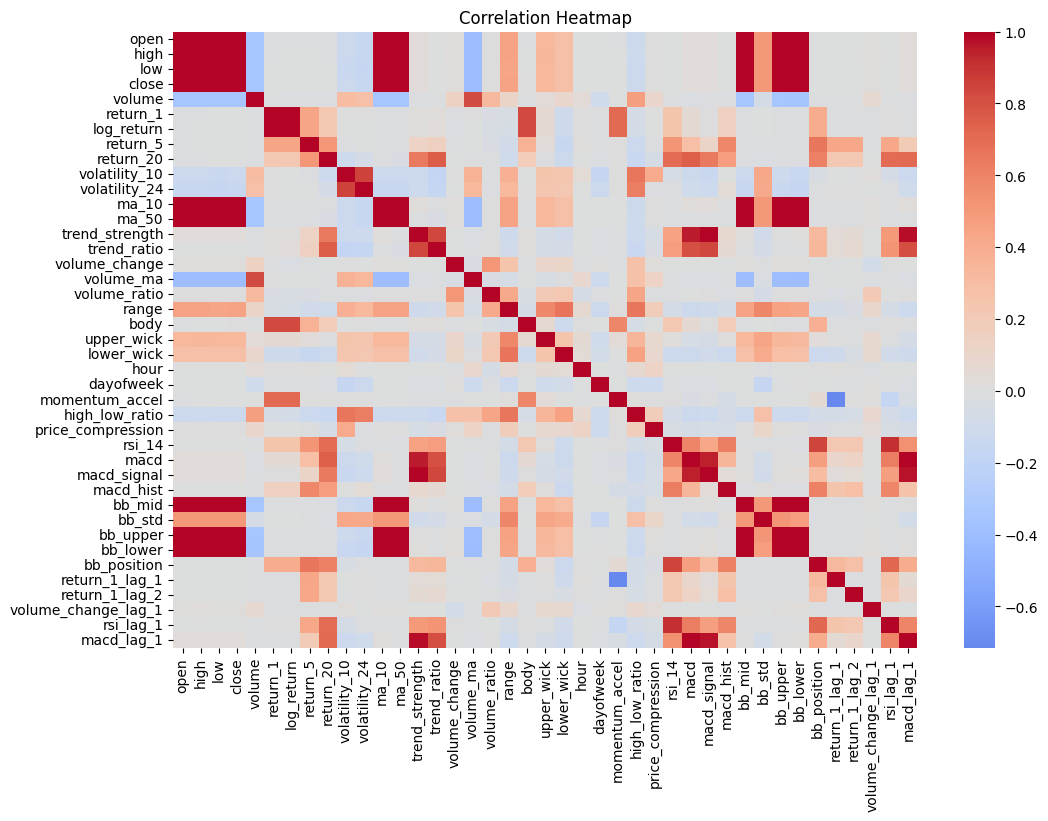

In [80]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

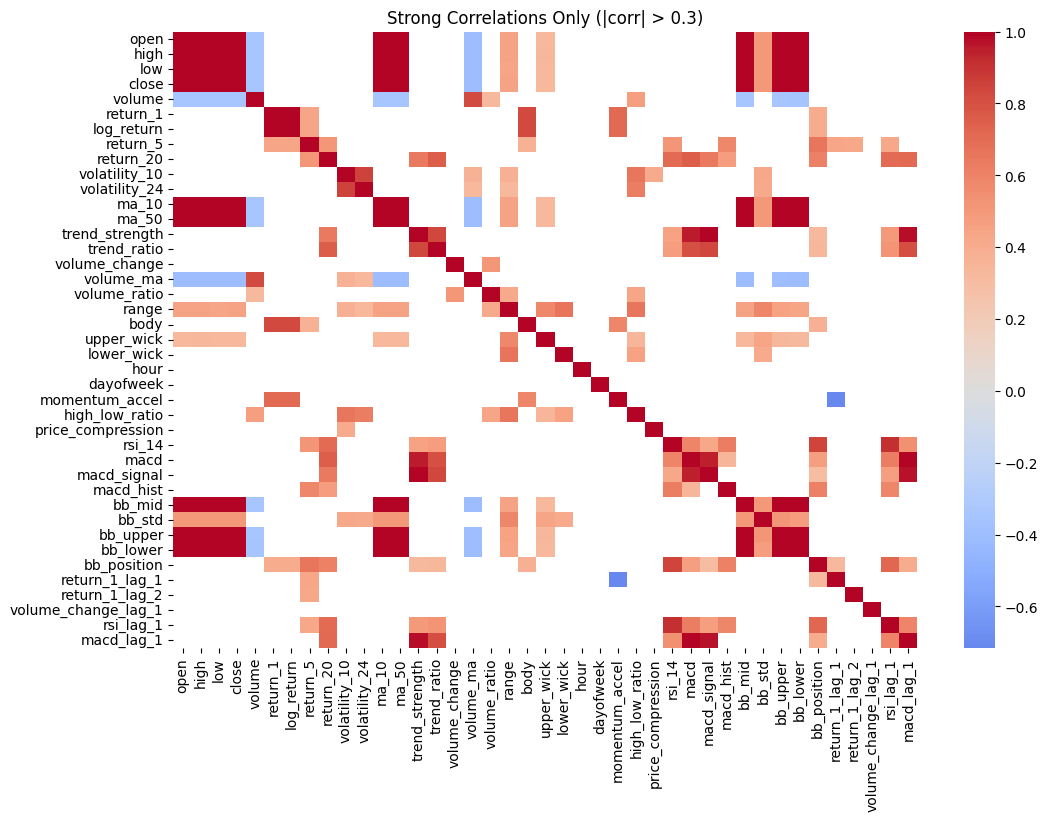

In [81]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

# mask weak correlations
mask = np.abs(corr) < 0.3
filtered_corr = corr.mask(mask)

plt.figure(figsize=(12,8))

sns.heatmap(
    filtered_corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Strong Correlations Only (|corr| > 0.3)")
plt.show()

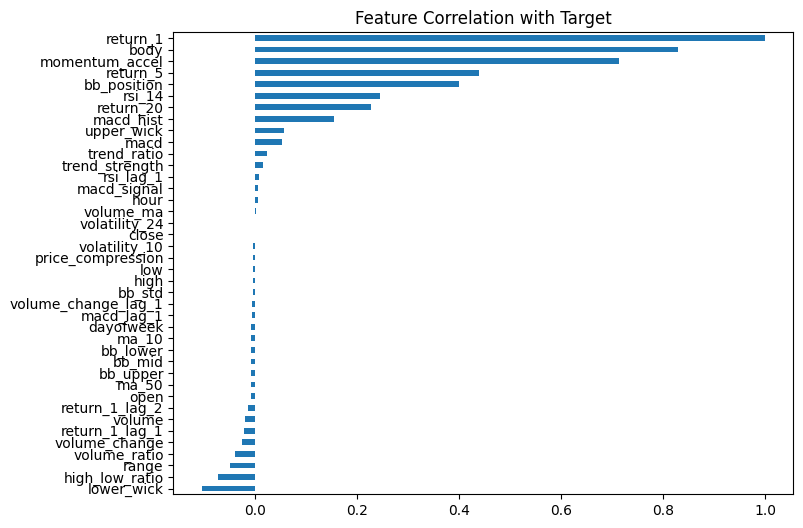

In [82]:
target = "log_return"

corr_target = df.corr(numeric_only=True)[target].sort_values()

plt.figure(figsize=(8,6))
corr_target.drop(target).plot(kind="barh")
plt.title("Feature Correlation with Target")
plt.show()